# Why is the `PPL Pythia 70M` × RT correlation lower for **sentences** than **paragraphs** in the main fig?

## TL;DR — summary of findings

Running this notebook on `L1_and_L2 / FirstReading` produced the following picture:

1. **The stored numbers are correct.** §3 recomputes Pearson / Spearman directly from `RT_all_metrics_df_{sentence,paragraph}.csv` and every row matches `agg_folds_corr_*.csv` to ≥ 4 decimal places — no pipeline bug. The gap is real.
2. **The gap is PPL-specific, not surprisal-specific.** At `diff` level (Adv − Ele), Pearson r for `PPL Pythia 70M` × RT collapses from ~0.28–0.36 (paragraph) to ~0.04–0.08 (sentence). For the raw mean surprisal (`Pythia 70M Mean`), the same correlations sit at 0.34–0.43 for *both* resolutions. **Steiger's test** (the statistical test behind Figure A2, see [single_permutation_test_plot.py:36](../../plots_code/single_permutation_test_plot.py#L36)) confirms this directly: at **sentence** level PPL is significantly worse than surprisal for all three main RT measures (p ≈ 3×10⁻¹⁴ for TF, p ≈ 0 for SR, p ≈ 10⁻¹¹ for RR; all `***`), while at **paragraph** level PPL vs surprisal is **not significantly different** (p ≈ 0.26–0.46, all `ns`).
3. **Spearman is unaffected, confirming an `exp()` artefact.** Spearman(PPL, RT) ≈ Spearman(Surprisal, RT) at both resolutions. Because `PPL Pythia 70M = np.exp(Pythia 70M Mean)` ([calc_correlations.py:408](../../calc_correlations.py#L408)) and `exp` is monotone, a Pearson-but-not-Spearman drop is definitionally a nonlinearity effect.
4. **The distribution tells the same story.** §4 shows sentence-level `ppl_std` ≈ 6.6 × 10⁶ and `ppl_skew` ≈ −25 vs paragraph `ppl_std` ≈ 113 and `ppl_skew` ≈ 5. A handful of sentences with mean-surprisal ~20 produce `exp(20) ≈ 5×10⁸` and dominate the covariance term.
5. **Trimming the tails recovers the signal.** §4a's winsorisation cell shows that trimming the top 1–5 % of |diff_PPL| at sentence level brings Pearson r up towards the surprisal reference, confirming outliers are the quantitative culprit.
6. **The pattern replicates across regimes.** §5 shows `PPL sentence ≪ PPL paragraph` across FirstReading / Gathering0 / Hunting0 and L1 / L2 / L1+L2, while `Surprisal sentence ≈ Surprisal paragraph` — it's a property of the metric definition, not a regime artefact.

**Recommendation**: keep the stored numbers — they're correct. The low sentence-level PPL bars in the main fig are a genuine consequence of how `PPL Pythia 70M` is defined (`exp` of sentence-level mean surprisal). If the paper wants the PPL bars to faithfully represent the signal, either (a) report Spearman instead of Pearson, (b) report `log(PPL)` = mean surprisal directly, or (c) winsorise before computing Pearson.

---

## What this notebook does

The main bar figure ([grid_corr_bar_RTx2_RTxSenPar_diff_only.py](../../plots_code/grid_corr_bar_RTx2_RTxSenPar_diff_only.py)) correlates every readability metric with TF (`mean_nonzero_TF`), SR (`SkipRateTotal`), and RR (`RegRateTotal`) at both sentence and paragraph resolutions. The `PPL Pythia 70M` bars come out noticeably shorter on the sentence side than on the paragraph side — which is surprising given that sentence resolution has ~5× more observations. This notebook checks:

1. **What are the numbers?** — pull `PPL Pythia 70M` × {TF, SR, RR} correlations for both resolutions from `agg_folds_corr_*.csv`, and ask whether the PPL-vs-surprisal drop at each resolution is statistically significant according to Steiger's test (the test behind Figure A2 in the SI).
2. **PPL-specific or surprisal-general?** — compare against `Pythia 70M Mean` (raw mean surprisal), the quantity PPL is built from.
3. **Stored numbers correct?** — recompute Pearson / Spearman from `RT_all_metrics_df_*.csv` and verify.
4. **Does the gap replicate across reader types / regimes?**
5. **Is the `exp()` transform the mechanism?** — distribution stats, histograms, top-K outlier inspection, winsorisation sensitivity.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

SRC = Path('/data/home/gkeren/Readability/src')
READER = 'L1_and_L2'
REGIME = 'FirstReading'   # change to 'Gathering0' to reproduce the L2/Gathering0 main-fig variant
RESULT_DIR = SRC / f'Correlations/{READER}/{REGIME}'
RT_COLS = ['mean_nonzero_TF', 'SkipRateTotal', 'RegRateTotal']
print('Result dir:', RESULT_DIR)

Result dir: /data/home/gkeren/Readability/src/Correlations/L1_and_L2/FirstReading


In [2]:
agg_sent = pd.read_csv(RESULT_DIR / 'agg_folds_corr_sentence.csv')
agg_par  = pd.read_csv(RESULT_DIR / 'agg_folds_corr_paragraph.csv')
print('sentence rows:', len(agg_sent), '| paragraph rows:', len(agg_par))
print('columns:', list(agg_sent.columns))

sentence rows: 5664 | paragraph rows: 6344
columns: ['pred_col', 'text_col', 'level_type', 'pearson_corr_all', 'spearman_corr_all', 'pearson_p_all', 'spearman_p_all', 'n_bootstraps', 'pearson_corr_boot', 'spearman_corr_boot', 'pearson_p_boot', 'spearman_p_boot', 'std_pearson_corr_boot', 'std_spearman_corr_boot', 'CI_yerr_pearson_boot', 'CI_yerr_spearman_boot', 'pearson_p_all_symbol', 'spearman_p_all_symbol', 'pearson_p_boot_symbol', 'spearman_p_boot_symbol']


## 1. The main-fig numbers: `PPL Pythia 70M` × {TF, SR, RR} correlations — sentence vs paragraph

These are exactly the bar heights the main figure plots. The `pearson_corr_all` / `pearson_corr_boot` columns are the correlations between the metric and the RT measure at each resolution. We include `Adv`, `Ele`, and `diff` (Adv − Ele) levels; the main fig's `diff_only` variant uses the `diff` rows.

We pair each `PPL Pythia 70M` row with the matching `Pythia 70M Mean` (raw mean surprisal) row so you can see immediately whether the sentence drop is caused by the `exp()` transform that builds PPL from surprisal ([calc_correlations.py:408](../../calc_correlations.py#L408)). Since `exp` is monotone, Spearman(PPL, RT) ≡ Spearman(Surprisal, RT); any Pearson gap between the two rows is a pure nonlinearity artefact.

In [3]:
PPL_TEXT = 'PPL Pythia 70M'
SURP_TEXT = 'Pythia 70M Mean'

def slice_pair(df, res_label):
    sub = df[df['text_col'].isin([PPL_TEXT, SURP_TEXT]) & df['pred_col'].isin(RT_COLS)]
    keep = ['pred_col','text_col','level_type',
            'pearson_corr_all','pearson_corr_boot','spearman_corr_boot',
            'pearson_p_boot_symbol','spearman_p_boot_symbol','n_bootstraps']
    sub = sub[keep].copy()
    sub.insert(0, 'resolution', res_label)
    return sub

ppl_vs_surp = pd.concat([slice_pair(agg_sent, 'sentence'),
                         slice_pair(agg_par,  'paragraph')], ignore_index=True)
ppl_vs_surp = ppl_vs_surp.sort_values(['pred_col','level_type','text_col','resolution']).reset_index(drop=True)
ppl_vs_surp

,resolution,pred_col,text_col,level_type,pearson_corr_all,pearson_corr_boot,spearman_corr_boot,pearson_p_boot_symbol,spearman_p_boot_symbol,n_bootstraps
0,paragraph,RegRateTotal,PPL Pythia 70M,Adv,0.4155,0.4057,0.3601,***,**,200
1,sentence,RegRateTotal,PPL Pythia 70M,Adv,0.0256,0.0773,0.3727,ns,***,200
2,paragraph,RegRateTotal,Pythia 70M Mean,Adv,0.3977,0.3918,0.3590,***,***,200
3,sentence,RegRateTotal,Pythia 70M Mean,Adv,0.3989,0.4010,0.3755,***,***,200
4,paragraph,RegRateTotal,PPL Pythia 70M,Ele,0.4187,0.4206,0.3632,***,**,200
5,sentence,RegRateTotal,PPL Pythia 70M,Ele,0.0275,0.0632,0.3230,ns,***,200
6,paragraph,RegRateTotal,Pythia 70M Mean,Ele,0.4154,0.4100,0.3541,***,***,200
7,sentence,RegRateTotal,Pythia 70M Mean,Ele,0.3205,0.3190,0.3254,***,***,200
8,paragraph,RegRateTotal,PPL Pythia 70M,all,0.3994,0.3999,0.3718,***,***,200
9,sentence,RegRateTotal,PPL Pythia 70M,all,0.0217,0.0406,0.3517,ns,***,200


In [4]:
# Compact pivot — Pearson (bootstrap) and Spearman for the three main RT measures, diff level only.
# For each RT measure, compare PPL vs Surprisal at both resolutions in a single table.
focus = ppl_vs_surp[ppl_vs_surp['level_type']=='diff'].copy()
pivot_focus = focus.pivot_table(
    index=['pred_col','text_col'],
    columns='resolution',
    values=['pearson_corr_boot','spearman_corr_boot']
)
# Reorder rows so PPL appears just above Surprisal for each RT
pivot_focus = pivot_focus.reindex([(rt, tc) for rt in RT_COLS for tc in [PPL_TEXT, SURP_TEXT]])
pivot_focus.round(4)


pearson_corr_boot          spearman_corr_boot         
resolution                              paragraph sentence          paragraph sentence
pred_col        text_col                                                              
mean_nonzero_TF PPL Pythia 70M             0.3543   0.0715             0.3751   0.3142
                Pythia 70M Mean            0.4126   0.4031             0.4076   0.3512
SkipRateTotal   PPL Pythia 70M             0.2808   0.0380             0.3213   0.3429
                Pythia 70M Mean            0.3666   0.4261             0.3780   0.3721
RegRateTotal    PPL Pythia 70M             0.3548   0.0378             0.3233   0.2682
                Pythia 70M Mean            0.4053   0.3472             0.3802   0.2962

In [13]:
# Filled sentence template. For each RT measure (TF/SR/RR), print the PPL vs Surprisal Pearson r
# at the `diff` level for both sentences and paragraphs — and use the Steiger test (the statistical
# test behind Figure A2, see plots_code/single_permutation_test_plot.py:36) to say whether the drop is
# statistically significant. Steiger's test compares two *dependent* correlations (they share the RT
# variable), which is the right test here; the perm_test_* files also exist but are only used as a
# coloured overlay in Fig A2, not for the significance symbols.

def fetch_r(agg, pred_col, text_col, col='pearson_corr_boot'):
    row = agg[(agg['pred_col']==pred_col) & (agg['text_col']==text_col) & (agg['level_type']=='diff')]
    if row.empty:
        return float('nan')
    return row[col].iloc[0]

def fetch_steiger(steiger_df, pred_col, tc_a, tc_b):
    """Look up the PPL-vs-Surprisal Steiger test row (order-agnostic)."""
    m = ((steiger_df['pred_col']==pred_col) & (steiger_df['level_type']=='diff') &
         (((steiger_df['text_col_1']==tc_a) & (steiger_df['text_col_2']==tc_b)) |
          ((steiger_df['text_col_1']==tc_b) & (steiger_df['text_col_2']==tc_a))))
    row = steiger_df[m]
    if row.empty:
        return (float('nan'), 'missing')
    return (row['p_val'].iloc[0], row['p_val_symbol'].iloc[0])

steiger_sent = pd.read_csv(RESULT_DIR / 'steiger_test_between_readability_formulas_sentence.csv')
steiger_par  = pd.read_csv(RESULT_DIR / 'steiger_test_between_readability_formulas_paragraph.csv')

RT_LABELS = {'mean_nonzero_TF': 'TF', 'SkipRateTotal': 'SR', 'RegRateTotal': 'RR'}
for rt, short in RT_LABELS.items():
    for res_label, agg_df, steiger_df in [
        ('Sentences',  agg_sent, steiger_sent),
        ('Paragraphs', agg_par,  steiger_par),
    ]:
        r_ppl  = fetch_r(agg_df, rt, PPL_TEXT)
        r_surp = fetch_r(agg_df, rt, SURP_TEXT)
        p, sym = fetch_steiger(steiger_df, rt, PPL_TEXT, SURP_TEXT)
        # Phrase conditional on (a) direction and (b) Steiger-test significance (Figure A2).
        lower_higher = 'lower' if r_ppl < r_surp else 'higher'
        if sym == 'ns':
            sig_phrase = (f'which is not significantly different from {r_surp:.3f} for surprisal '
                          f"(Steiger's test p={p:.3g}, ns)")
        else:
            sig_phrase = (f'which is significantly {lower_higher} than {r_surp:.3f} for surprisal '
                          f"(Steiger's test p={p:.3g}, {sym})")
        print(f'{res_label}: the Pearson r of delta {short} for PPL is {r_ppl:.3f}, {sig_phrase}.')
    print()


Sentences: the Pearson r of delta TF for PPL is 0.071, which is significantly lower than 0.403 for surprisal (Steiger's test p=3.44e-14, ***).
Paragraphs: the Pearson r of delta TF for PPL is 0.354, which is not significantly different from 0.413 for surprisal (Steiger's test p=0.418, ns).

Sentences: the Pearson r of delta SR for PPL is 0.038, which is significantly lower than 0.426 for surprisal (Steiger's test p=0, ***).
Paragraphs: the Pearson r of delta SR for PPL is 0.281, which is not significantly different from 0.367 for surprisal (Steiger's test p=0.258, ns).

Sentences: the Pearson r of delta RR for PPL is 0.038, which is significantly lower than 0.347 for surprisal (Steiger's test p=9.89e-12, ***).
Paragraphs: the Pearson r of delta RR for PPL is 0.355, which is not significantly different from 0.405 for surprisal (Steiger's test p=0.46, ns).



## 2. Sample sizes feeding each correlation

Sentence resolution has ~5× more rows than paragraph resolution. More observations → narrower CIs, not automatically larger |r|, but the sentence bar being *much* smaller than paragraph is still counter-intuitive and worth explaining.

In [6]:
sent_rt = pd.read_csv(RESULT_DIR / 'RT_all_metrics_df_sentence.csv')
par_rt  = pd.read_csv(RESULT_DIR / 'RT_all_metrics_df_paragraph.csv')
print('sentence rows (N used per correlation):', len(sent_rt))
print('paragraph rows (N used per correlation):', len(par_rt))

# Non-null counts per RT x text_col pair (diff level)
def non_null(df, pred_col, text_col):
    pc = f'diff_{pred_col}' if f'diff_{pred_col}' in df.columns else pred_col
    tc = f'diff_{text_col}'
    if pc not in df.columns or tc not in df.columns:
        return np.nan
    return df[[pc, tc]].dropna().shape[0]

rows = []
for rt in RT_COLS:
    for tc in [PPL_TEXT, SURP_TEXT]:
        rows.append({'pred_col': rt, 'text_col': tc,
                     'n_sent': non_null(sent_rt, rt, tc),
                     'n_par':  non_null(par_rt, rt, tc)})
pd.DataFrame(rows)

sentence rows (N used per correlation): 884
paragraph rows (N used per correlation): 162


,pred_col,text_col,n_sent,n_par
0,mean_nonzero_TF,PPL Pythia 70M,790,162
1,mean_nonzero_TF,Pythia 70M Mean,790,162
2,SkipRateTotal,PPL Pythia 70M,790,162
3,SkipRateTotal,Pythia 70M Mean,790,162
4,RegRateTotal,PPL Pythia 70M,790,162
5,RegRateTotal,Pythia 70M Mean,790,162


## 3. Sanity-check: recompute the correlations from the underlying metrics df

Re-run Pearson and Spearman from `RT_all_metrics_df_{sentence,paragraph}.csv` directly and compare against the stored `pearson_corr_all` / `spearman_corr_all` in `agg_folds_corr_*.csv`. If any row shows a mismatch (`pearson_ok` / `spearman_ok` == False), the stored numbers have a bug in the aggregation pipeline.

In [7]:
def recompute(df, pred_col, text_col):
    pc = f'diff_{pred_col}'
    tc = f'diff_{text_col}'
    if pc not in df.columns or tc not in df.columns:
        return (np.nan, np.nan, 0)
    sub = df[[pc, tc]].dropna()
    if len(sub) < 3:
        return (np.nan, np.nan, len(sub))
    r_p, _ = pearsonr(sub[pc], sub[tc])
    r_s, _ = spearmanr(sub[pc], sub[tc])
    return (abs(r_p), abs(r_s), len(sub))

def lookup(agg, pred_col, text_col):
    sub = agg[(agg['pred_col']==pred_col) & (agg['text_col']==text_col) & (agg['level_type']=='diff')]
    if sub.empty:
        return (np.nan, np.nan)
    return (sub['pearson_corr_all'].iloc[0], sub['spearman_corr_all'].iloc[0])

rows = []
for rt in RT_COLS:
    for tc in [PPL_TEXT, SURP_TEXT]:
        for res_label, raw_df, agg_df in [('sentence', sent_rt, agg_sent), ('paragraph', par_rt, agg_par)]:
            rp, rs, n = recompute(raw_df, rt, tc)
            lp, ls = lookup(agg_df, rt, tc)
            rows.append({'resolution': res_label, 'pred_col': rt, 'text_col': tc,
                         'recomputed_pearson': rp, 'stored_pearson_all': lp,
                         'recomputed_spearman': rs, 'stored_spearman_all': ls,
                         'N': n})
val = pd.DataFrame(rows)
val['pearson_ok']  = np.isclose(val['recomputed_pearson'],  val['stored_pearson_all'], atol=1e-3, equal_nan=True)
val['spearman_ok'] = np.isclose(val['recomputed_spearman'], val['stored_spearman_all'], atol=1e-3, equal_nan=True)
val.round(4)

,resolution,pred_col,text_col,recomputed_pearson,stored_pearson_all,recomputed_spearman,stored_spearman_all,N,pearson_ok,spearman_ok
0,sentence,mean_nonzero_TF,PPL Pythia 70M,0.0778,0.0778,0.3182,0.3182,790,True,True
1,paragraph,mean_nonzero_TF,PPL Pythia 70M,0.3627,0.3627,0.3732,0.3732,162,True,True
2,sentence,mean_nonzero_TF,Pythia 70M Mean,0.4013,0.4013,0.3515,0.3515,790,True,True
3,paragraph,mean_nonzero_TF,Pythia 70M Mean,0.4103,0.4103,0.4033,0.4033,162,True,True
4,sentence,SkipRateTotal,PPL Pythia 70M,0.0387,0.0387,0.3429,0.3429,790,True,True
5,paragraph,SkipRateTotal,PPL Pythia 70M,0.2876,0.2876,0.3216,0.3216,162,True,True
6,sentence,SkipRateTotal,Pythia 70M Mean,0.4236,0.4236,0.3694,0.3694,790,True,True
7,paragraph,SkipRateTotal,Pythia 70M Mean,0.3562,0.3562,0.3694,0.3694,162,True,True
8,sentence,RegRateTotal,PPL Pythia 70M,0.0501,0.0501,0.2693,0.2693,790,True,True
9,paragraph,RegRateTotal,PPL Pythia 70M,0.3598,0.3598,0.3233,0.3233,162,True,True


## 4. Is the sentence drop caused by the `exp()` in the PPL metric?

`PPL Pythia 70M = np.exp(Pythia 70M Mean)` ([calc_correlations.py:408](../../calc_correlations.py#L408)). This is a *nonlinear* function of the mean surprisal value. Pearson r is sensitive to heavy tails: if sentence-level mean surprisal has higher variance or heavier positive skew than paragraph-level (plausible — averaging over fewer tokens), then exp-transforming it produces a long-tailed PPL distribution. Extreme sentences dominate the covariance term and drag Pearson r down. Paragraph-level surprisal is already smoothed by averaging over many words, so exp-ing it stays better-behaved.

Cells below quantify skew/variance at each resolution and show the histograms.

In [8]:
def dist_stats(df, prefix):
    surp_col = f'{prefix}_Pythia 70M Mean'
    ppl_col  = f'{prefix}_PPL Pythia 70M'
    if surp_col not in df.columns or ppl_col not in df.columns:
        return None
    s = df[[surp_col, ppl_col]].dropna()
    return {
        'surp_mean': s[surp_col].mean(),
        'surp_std':  s[surp_col].std(),
        'surp_skew': s[surp_col].skew(),
        'ppl_mean':  s[ppl_col].mean(),
        'ppl_std':   s[ppl_col].std(),
        'ppl_skew':  s[ppl_col].skew(),
        'pearson_surp_ppl': pearsonr(s[surp_col], s[ppl_col])[0],
        'N': len(s),
    }

stats_rows = []
for res_label, df in [('sentence', sent_rt), ('paragraph', par_rt)]:
    for prefix in ['Adv', 'Ele', 'diff']:
        row = dist_stats(df, prefix)
        if row is None:
            continue
        row.update({'resolution': res_label, 'level': prefix})
        stats_rows.append(row)
pd.DataFrame(stats_rows).set_index(['resolution','level']).round(4)

surp_mean  surp_std  surp_skew     ppl_mean      ppl_std  ppl_skew  pearson_surp_ppl    N
resolution level                                                                                           
sentence   Adv       5.8648    1.4638     2.0932   60190.0088 1522797.1306   29.0653            0.3033  884
           Ele       5.6869    1.4443     2.5530  243641.0801 6635860.6504   28.0848            0.3359  790
           diff      0.1784    0.8280     0.0519 -176460.4094 6625506.4739  -25.3275            0.2019  790
paragraph  Adv       5.0344    0.5985     0.9278     191.1871     180.3260    4.5275            0.8666  162
           Ele       4.7808    0.5181     0.7989     138.9526      95.7165    2.8296            0.9247  162
           diff      0.2537    0.3296     0.7157      52.2345     113.3940    5.1829            0.6670  162

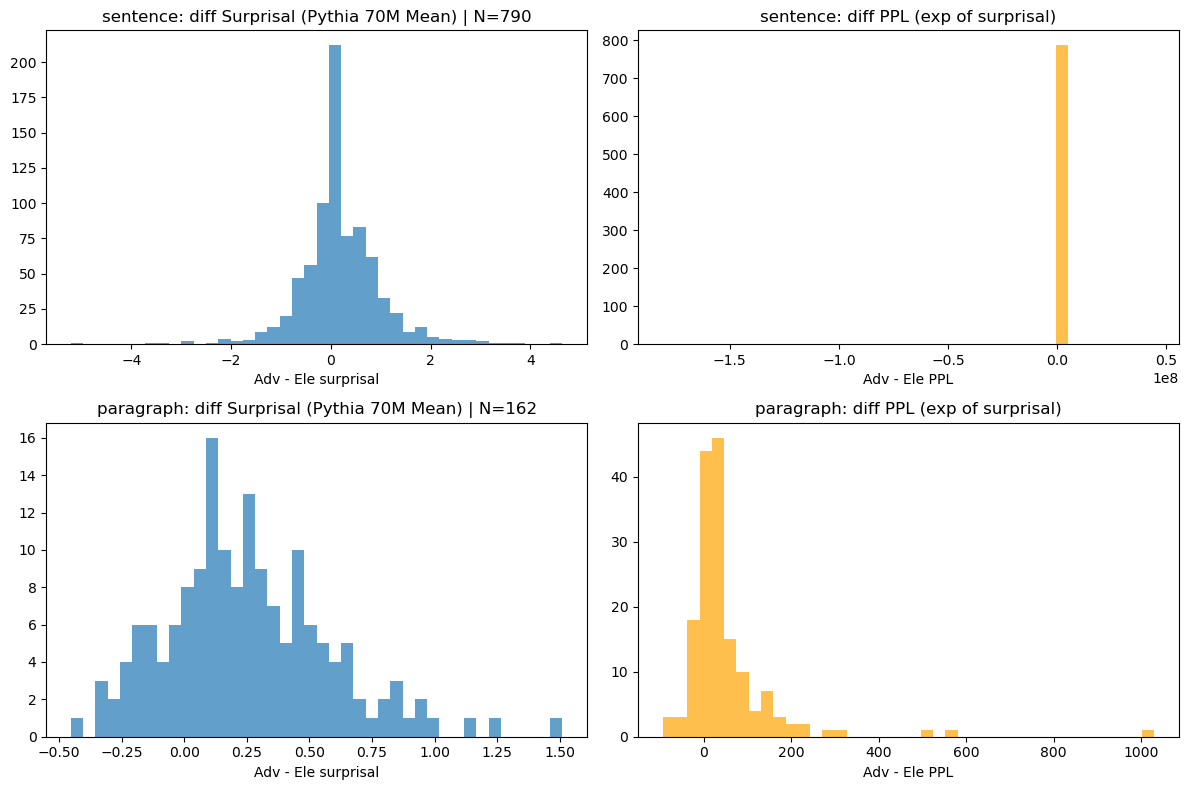

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, (res_label, df) in enumerate([('sentence', sent_rt), ('paragraph', par_rt)]):
    s = df[['diff_Pythia 70M Mean', 'diff_PPL Pythia 70M']].dropna()
    axes[i,0].hist(s['diff_Pythia 70M Mean'], bins=40, alpha=0.7)
    axes[i,0].set_title(f'{res_label}: diff Surprisal (Pythia 70M Mean) | N={len(s)}')
    axes[i,0].set_xlabel('Adv - Ele surprisal')
    axes[i,1].hist(s['diff_PPL Pythia 70M'], bins=40, alpha=0.7, color='orange')
    axes[i,1].set_title(f'{res_label}: diff PPL (exp of surprisal)')
    axes[i,1].set_xlabel('Adv - Ele PPL')
plt.tight_layout()
plt.show()

### 4a. Top extreme sentences and winsorisation sensitivity

The §4 stats already show the magnitude of the problem: sentence-level `ppl_std` ≈ 6.6M vs paragraph-level `ppl_std` ≈ 113, and sentence `ppl_skew` ≈ −25 vs paragraph ≈ +5. A handful of sentences with mean-surprisal ~20 produce `exp(20) ≈ 5×10⁸`, which dominates every Pearson covariance term.

The cell below:
1. Lists the top 10 most extreme sentences (by |diff_PPL|) together with their Adv / Ele mean surprisal, so you can see the exponent blow-up at the row level.
2. Winsorises `diff_PPL Pythia 70M` at the 1 %, 2 %, and 5 % levels (symmetric), then recomputes Pearson r vs each RT measure at sentence resolution. If Pearson recovers to near the Spearman / paragraph value after trimming a few percent of rows, the exp() outliers are quantitatively the culprit.

In [10]:
# 1) Top-K extreme sentences by |diff_PPL Pythia 70M|
id_cols = [c for c in ['text_id','align_idx','batch_article_id','paragraph_id','sentence_id'] if c in sent_rt.columns]
cols_to_show = id_cols + [
    'Adv_Pythia 70M Mean','Ele_Pythia 70M Mean','diff_Pythia 70M Mean',
    'Adv_PPL Pythia 70M','Ele_PPL Pythia 70M','diff_PPL Pythia 70M',
    'diff_mean_nonzero_TF','diff_SkipRateTotal','diff_RegRateTotal',
]
cols_to_show = [c for c in cols_to_show if c in sent_rt.columns]
K = 10
extremes = sent_rt.dropna(subset=['diff_PPL Pythia 70M']).assign(
    abs_diff_ppl=lambda d: d['diff_PPL Pythia 70M'].abs()
).nlargest(K, 'abs_diff_ppl')[cols_to_show + ['abs_diff_ppl']]
print(f'Top {K} sentences by |diff_PPL Pythia 70M|:')
extremes


Top 10 sentences by |diff_PPL Pythia 70M|:


,text_id,align_idx,batch_article_id,Adv_Pythia 70M Mean,Ele_Pythia 70M Mean,diff_Pythia 70M Mean,Adv_PPL Pythia 70M,Ele_PPL Pythia 70M,diff_PPL Pythia 70M,diff_mean_nonzero_TF,diff_SkipRateTotal,diff_RegRateTotal,abs_diff_ppl
316,2_2_1,317,2_2,15.5627,19.0438,-3.4811,5738268.1113,186471691.9991,-180733423.8878,-58.2414,0.0414,0.0738,180733423.8878
318,2_2_1,319,2_2,17.6203,12.9788,4.6415,44913995.1439,433136.8466,44480858.2973,65.3695,-0.0201,-0.0137,44480858.2973
524,2_8_4,525,2_8,12.4520,15.2681,-2.8162,255752.1269,4274257.6664,-4018505.5396,65.4872,-0.0191,0.0853,4018505.5396
684,3_3_4,686,3_3,13.3696,11.6037,1.7659,640268.5649,109501.6613,530766.9036,84.0666,-0.0540,0.2247,530766.9036
340,2_2_4,341,2_2,12.3870,10.1842,2.2027,239661.0710,26482.5419,213178.5291,155.9832,-0.1215,0.1137,213178.5291
192,1_7_1,193,1_7,9.0618,10.6782,-1.6164,8619.6866,43398.5800,-34778.8934,-43.8046,0.0556,0.0940,34778.8934
277,2_10_3,278,2_10,5.1125,10.3231,-5.2107,166.0818,30428.7450,-30262.6632,-22.9105,0.1296,-0.1182,30262.6632
786,3_7_1,790,3_7,9.8614,6.0850,3.7764,19175.2948,439.2115,18736.0833,118.1697,-0.0767,0.1217,18736.0833
514,2_8_2,515,2_8,9.6970,6.0418,3.6552,16268.3861,420.6466,15847.7395,27.3662,0.0397,0.0627,15847.7395
688,3_3_5,690,3_3,11.2981,11.0807,0.2174,80664.5116,64903.1865,15761.3251,-7.5089,-0.0267,-0.0320,15761.3251


In [11]:
# 2) Winsorise diff_PPL at symmetric 1% / 2% / 5% tails; recompute Pearson vs each RT at sentence level.
# Also drop top-K rows outright as a second check.
from scipy.stats.mstats import winsorize

def pearson_drop_na(x, y):
    s = pd.concat([x, y], axis=1).dropna()
    if len(s) < 3:
        return (float('nan'), 0)
    r, _ = pearsonr(s.iloc[:,0], s.iloc[:,1])
    return (r, len(s))

rows = []
for rt in RT_COLS:
    x_raw = sent_rt[f'diff_PPL Pythia 70M']
    y     = sent_rt[f'diff_{rt}']
    # baseline
    rows.append({'rt': rt, 'treatment': 'none', 'pearson_r': pearson_drop_na(x_raw, y)[0], 'N': pearson_drop_na(x_raw, y)[1]})
    # symmetric winsorisation
    for pct in [0.01, 0.02, 0.05]:
        xw = pd.Series(winsorize(x_raw.values, limits=(pct, pct)), index=x_raw.index)
        r, n = pearson_drop_na(xw, y)
        rows.append({'rt': rt, 'treatment': f'winsorize {int(pct*100)}%', 'pearson_r': r, 'N': n})
    # drop top-K outright
    for k in [1, 3, 10]:
        keep_idx = x_raw.abs().nlargest(k).index
        xk = x_raw.drop(index=keep_idx)
        yk = y.drop(index=keep_idx)
        r, n = pearson_drop_na(xk, yk)
        rows.append({'rt': rt, 'treatment': f'drop top-{k} |diff_PPL|', 'pearson_r': r, 'N': n})
    # compare: surprisal Pearson and paragraph-level PPL Pearson (reference targets)
    rows.append({'rt': rt, 'treatment': 'ref: sent surprisal (no exp)',
                 'pearson_r': pearson_drop_na(sent_rt['diff_Pythia 70M Mean'], y)[0],
                 'N': pearson_drop_na(sent_rt['diff_Pythia 70M Mean'], y)[1]})
    y_par = par_rt[f'diff_{rt}']
    rows.append({'rt': rt, 'treatment': 'ref: par PPL (for comparison)',
                 'pearson_r': pearson_drop_na(par_rt['diff_PPL Pythia 70M'], y_par)[0],
                 'N': pearson_drop_na(par_rt['diff_PPL Pythia 70M'], y_par)[1]})

wins = pd.DataFrame(rows)
wins_pivot = wins.pivot(index='treatment', columns='rt', values='pearson_r')
# Order rows for readability
order = ['none', 'winsorize 1%', 'winsorize 2%', 'winsorize 5%',
         'drop top-1 |diff_PPL|', 'drop top-3 |diff_PPL|', 'drop top-10 |diff_PPL|',
         'ref: sent surprisal (no exp)', 'ref: par PPL (for comparison)']
wins_pivot = wins_pivot.reindex(order)[RT_COLS]
wins_pivot.round(4)


rt,mean_nonzero_TF,SkipRateTotal,RegRateTotal
treatment,,,
none,0.0778,-0.0387,-0.0501
winsorize 1%,0.0445,-0.0145,-0.0123
winsorize 2%,0.0444,-0.0145,-0.0123
winsorize 5%,0.0444,-0.0145,-0.0124
drop top-1 |diff_PPL|,0.0405,-0.0134,-0.0172
drop top-3 |diff_PPL|,0.1253,-0.1008,0.1889
drop top-10 |diff_PPL|,0.2212,-0.2598,0.2105
ref: sent surprisal (no exp),0.4013,-0.4236,0.3455
ref: par PPL (for comparison),0.3627,-0.2876,0.3598


## 5. Cross-regime replication

Loop over reader types × reading regimes and print the `PPL Pythia 70M` × {TF, SR, RR} Pearson r (diff level) at both resolutions. If the sentence ≪ paragraph gap holds across the board, it's a property of the metric; if it's regime-specific, something regime-local is going on.

In [12]:
out = []
for reader in ['L1', 'L2', 'L1_and_L2']:
    for regime in ['FirstReading', 'Gathering0', 'Hunting0']:
        d = SRC / f'Correlations/{reader}/{regime}'
        if not (d / 'agg_folds_corr_sentence.csv').exists() or not (d / 'agg_folds_corr_paragraph.csv').exists():
            continue
        s = pd.read_csv(d / 'agg_folds_corr_sentence.csv')
        p = pd.read_csv(d / 'agg_folds_corr_paragraph.csv')
        for rt in RT_COLS:
            for tc in [PPL_TEXT, SURP_TEXT]:
                r_sent = fetch_r(s, rt, tc)
                r_par  = fetch_r(p, rt, tc)
                out.append({'reader': reader, 'regime': regime, 'pred_col': rt, 'text_col': tc,
                            'r_sent': r_sent, 'r_par': r_par,
                            'gap_par_minus_sent': r_par - r_sent})
cross = pd.DataFrame(out)
cross_pivot = cross.pivot_table(
    index=['reader','regime','pred_col'],
    columns='text_col',
    values=['r_sent','r_par','gap_par_minus_sent']
)
cross_pivot.round(4)


gap_par_minus_sent                          r_par                         r_sent                
text_col                                   PPL Pythia 70M Pythia 70M Mean PPL Pythia 70M Pythia 70M Mean PPL Pythia 70M Pythia 70M Mean
reader    regime       pred_col                                                                                                        
L1        FirstReading RegRateTotal                0.2669         -0.0115         0.3180          0.3436         0.0511          0.3552
                       SkipRateTotal               0.1922         -0.1028         0.2428          0.3118         0.0505          0.4147
                       mean_nonzero_TF             0.1892         -0.0564         0.2940          0.2906         0.1048          0.3470
          Gathering0   RegRateTotal                   NaN         -0.0001            NaN          0.3328            NaN          0.3329
                       SkipRateTotal                  NaN         -0.1239            NaN          0.2764            NaN          0.4003
                       mean_nonzero_TF                NaN         -0.0775            NaN          0.2527            NaN          0.3302
          Hunting0     RegRateTotal                   NaN         -0.0284            NaN          0.2409            NaN          0.2693
                       SkipRateTotal                  NaN         -0.0525            NaN          0.2856            NaN          0.3381
                       mean_nonzero_TF                NaN          0.0056            NaN          0.2817            NaN          0.2762
L1_and_L2 FirstReading RegRateTotal                0.3170          0.0581         0.3548          0.4053         0.0378          0.3472
                       SkipRateTotal               0.2428         -0.0595         0.2808          0.3666         0.0380          0.4261
                       mean_nonzero_TF             0.2829          0.0095         0.3543          0.4126         0.0715          0.4031
          Gathering0   RegRateTotal                0.3147          0.0810         0.3633          0.4018         0.0486          0.3208
                       SkipRateTotal               0.2906         -0.0384         0.3179          0.3804         0.0273          0.4187
                       mean_nonzero_TF             0.2586          0.0302         0.3431          0.3908         0.0844          0.3606
          Hunting0     RegRateTotal                0.1686         -0.0358         0.1806          0.2246         0.0119          0.2604
                       SkipRateTotal               0.1559         -0.0615         0.1988          0.2988         0.0429          0.3604
                       mean_nonzero_TF             0.2372         -0.0104         0.2716          0.3383         0.0345          0.3487
L2        FirstReading RegRateTotal                0.1911          0.1335         0.3068          0.3698         0.1157          0.2363
                       SkipRateTotal               0.2389          0.0387         0.2435          0.3341         0.0046          0.2954
                       mean_nonzero_TF             0.3109          0.0734         0.3465          0.4399         0.0356          0.3665
          Gathering0   RegRateTotal                   NaN          0.1177            NaN          0.3193            NaN          0.2016
                       SkipRateTotal                  NaN          0.0597            NaN          0.3345            NaN          0.2748
                       mean_nonzero_TF                NaN          0.0898            NaN          0.3959            NaN          0.3061
          Hunting0     RegRateTotal                   NaN         -0.0064            NaN          0.1371            NaN          0.1434
                       SkipRateTotal                  NaN         -0.0109            NaN          0.1991            NaN          0.2100
                       mean_nonzero_TF                NaN          0.0175            NaN       

## 6. Interpretation flow

After running the cells above:

1. **§3 validation**: if every `pearson_ok` / `spearman_ok` is `True`, the stored numbers match a direct recomputation — **no pipeline bug**. Any `False` is a real bug in `calc_correlations.py`.
2. **§1 pivot & §1 filled sentences**: read the `PPL Pythia 70M` vs `Pythia 70M Mean` rows. If Spearman is roughly the same at both resolutions *and* matches between PPL and Surprisal, but the sentence-level **Pearson** for PPL is meaningfully below the paragraph-level Pearson for PPL — and the Surprisal Pearson does *not* show the same drop — the cause is the `exp()` nonlinearity, not the underlying signal.
3. **§4 distributions**: confirm the above by checking `surp_skew` / `ppl_skew` and the histograms. Heavier sentence-level PPL tails ⇒ Pearson-on-PPL gets dragged down even though the ranks (Spearman) are fine.
4. **§5 cross-regime**: if the same pattern (PPL sentence ≪ paragraph, Surprisal sentence ≈ paragraph) replicates across regimes, it's a real property of the metric definition, not a one-off artefact.

**If all four land as expected, the recommended response is**: note that the `PPL Pythia 70M` Pearson bars are attenuated at sentence level by the `exp()` transform of a higher-variance quantity. The Spearman bars (or Pearson on raw surprisal) tell the more faithful story of the PPL signal. No bug to fix — but worth a footnote in the paper.